# Ollama Local API Exploration

Exploring the Ollama REST API running on this machine at `http://localhost:11434`.

Covers both the raw REST endpoints (via `requests`) and the official `ollama` Python client:

- `GET /api/tags` — list local models
- `GET /api/ps` — list running/loaded models
- `POST /api/show` — model details
- `POST /api/generate` — single-turn completion (incl. streaming)
- `POST /api/chat` — multi-turn chat (incl. streaming, tool calling)
- `POST /api/embed` — embeddings

Make sure the Ollama server is running (`ollama serve`, or the menu-bar app) before executing cells.

In [1]:
import json
import requests
import ollama

BASE_URL = "http://localhost:11434"

def pretty(obj):
    print(json.dumps(obj, indent=2, default=str))

## List local models — `GET /api/tags`

In [2]:
resp = requests.get(f"{BASE_URL}/api/tags")
resp.raise_for_status()
models = resp.json()["models"]

for m in models:
    print(f"{m['name']:<28} {m['details'].get('parameter_size', ''):<10} {m['size'] / 1e9:.2f} GB")

deepseek-v4-pro:cloud                   0.00 GB
gemma4:latest                8.0B       9.61 GB
deepseek-coder:6.7b          7B         3.83 GB
deepseek-ocr:latest          3.3B       6.69 GB
qwen3-embedding:4b           4.0B       2.50 GB
qwen3-embedding:0.6b         595.78M    0.64 GB
qwen3.5:latest               9.7B       6.59 GB
llama3.1:8b                  8.0B       4.92 GB


In [3]:
# Same thing via the ollama python client
client = ollama.Client(host=BASE_URL)

for m in client.list()["models"]:
    print(m["model"])

deepseek-v4-pro:cloud
gemma4:latest
deepseek-coder:6.7b
deepseek-ocr:latest
qwen3-embedding:4b
qwen3-embedding:0.6b
qwen3.5:latest
llama3.1:8b


## Running / loaded models — `GET /api/ps`

Shows which models are currently resident in memory (VRAM/RAM) and when they'll be unloaded.

In [4]:
resp = requests.get(f"{BASE_URL}/api/ps")
pretty(resp.json())

{
  "models": []
}


## Model details — `POST /api/show`

In [5]:
MODEL = "gemma4:latest"  # swap for any model from the /api/tags list above

resp = requests.post(f"{BASE_URL}/api/show", json={"model": MODEL})
info = resp.json()
print("family:", info["details"]["family"])
print("parameter_size:", info["details"]["parameter_size"])
print("quantization:", info["details"]["quantization_level"])
print("\ntemplate:\n", info.get("template", ""))
print("\nmodelfile (first 500 chars):\n", info.get("modelfile", "")[:500])

family: gemma4
parameter_size: 8.0B
quantization: Q4_K_M

template:
 {{ .Prompt }}

modelfile (first 500 chars):
 # Modelfile generated by "ollama show"
# To build a new Modelfile based on this, replace FROM with:
# FROM gemma4:latest

FROM /Users/surendrashukla/.ollama/models/blobs/sha256-4c27e0f5b5adf02ac956c7322bd2ee7636fe3f45a8512c9aba5385242cb6e09a
TEMPLATE {{ .Prompt }}
RENDERER gemma4
PARSER gemma4
PARAMETER temperature 1
PARAMETER top_k 64
PARAMETER top_p 0.95
LICENSE """                                Apache License
                           Version 2.0, January 2004
                        http:/


## Single-turn completion — `POST /api/generate`

Lower-level than `/api/chat` — takes a raw prompt string rather than a message list, and doesn't apply chat templating unless you use `raw: false` (default).

In [6]:
resp = requests.post(
    f"{BASE_URL}/api/generate",
    json={
        "model": MODEL,
        "prompt": "Explain what a Bloom filter is in two sentences.",
        "stream": False,
    },
)
result = resp.json()
print(result["response"])
print(f"\n--- eval_count={result.get('eval_count')} eval_duration={result.get('eval_duration') / 1e9:.2f}s")

A Bloom filter is a probabilistic data structure used to test whether an element is a member of a set, with the ability to return "no" for sure but potentially returning "yes" incorrectly (a false positive). It achieves extremely high space efficiency by using multiple hash functions to set bits in a bit array, allowing it to quickly determine membership while requiring significantly less memory than traditional hash tables.

--- eval_count=141 eval_duration=2.54s


In [7]:
# Streaming variant: the endpoint returns newline-delimited JSON objects
with requests.post(
    f"{BASE_URL}/api/generate",
    json={"model": MODEL, "prompt": "Count from 1 to 5.", "stream": True},
    stream=True,
) as resp:
    for line in resp.iter_lines():
        if not line:
            continue
        chunk = json.loads(line)
        print(chunk["response"], end="", flush=True)
        if chunk.get("done"):
            print("\n\n[done]", chunk.get("done_reason"))

1

,

2

,

3

,

4

,

5



[done] stop


In [8]:
# Same streaming call via the python client — yields dicts, no manual JSON parsing needed
for chunk in client.generate(model=MODEL, prompt="Name three prime numbers.", stream=True):
    print(chunk["response"], end="", flush=True)

Here

 are

 three

 prime

 numbers

...

3

.

 **

5

**

## Multi-turn chat — `POST /api/chat`

Takes a `messages` list (`role` + `content`), same shape as OpenAI's chat format, and the server applies the model's chat template.

In [9]:
messages = [
    {"role": "system", "content": "You are a terse assistant. Answer in one sentence."},
    {"role": "user", "content": "What is the capital of Japan?"},
]

resp = requests.post(
    f"{BASE_URL}/api/chat",
    json={"model": MODEL, "messages": messages, "stream": False},
)
reply = resp.json()["message"]
print(reply["content"])

Tokyo is the capital of Japan.


In [10]:
# Continue the conversation by appending the assistant reply and a new user turn
messages.append(reply)
messages.append({"role": "user", "content": "What's a famous landmark there?"})

response = client.chat(model=MODEL, messages=messages)
print(response["message"]["content"])

Senso-ji Temple and Tokyo Skytree are notable landmarks there.


### Tool calling

Models with `tools` in their capabilities (check the `/api/tags` output above) can be given function schemas and will return `tool_calls` instead of plain text when appropriate.

In [11]:
def get_weather(city: str) -> str:
    return f"It's sunny and 24C in {city}."

tools = [
    {
        "type": "function",
        "function": {
            "name": "get_weather",
            "description": "Get the current weather for a city",
            "parameters": {
                "type": "object",
                "properties": {"city": {"type": "string", "description": "City name"}},
                "required": ["city"],
            },
        },
    }
]

response = client.chat(
    model=MODEL,
    messages=[{"role": "user", "content": "What's the weather in Tokyo?"}],
    tools=tools,
)

tool_calls = response["message"].get("tool_calls")
if tool_calls:
    for call in tool_calls:
        print("model wants to call:", call["function"]["name"], call["function"]["arguments"])
        result = get_weather(**call["function"]["arguments"])
        print("tool result:", result)
else:
    print(response["message"]["content"])

model wants to call: get_weather {'city': 'Tokyo'}
tool result: It's sunny and 24C in Tokyo.


## Vision / OCR — `deepseek-ocr`\n\nUnlike `gemma4` and the other text models above, `deepseek-ocr:latest` has the `vision` capability — it accepts an `images` field (base64-encoded) alongside the prompt, on both `/api/generate` and `/api/chat`.\n\nWe generate a synthetic test image with some rendered text (via Pillow) so this cell works offline without needing a sample photo on disk.

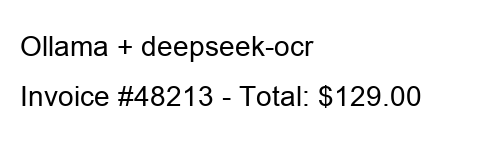

In [12]:
import base64
import io

from PIL import Image, ImageDraw, ImageFont

img = Image.new("RGB", (500, 150), color="white")
draw = ImageDraw.Draw(img)
try:
    font = ImageFont.truetype("/System/Library/Fonts/Supplemental/Arial.ttf", 28)
except OSError:
    font = ImageFont.load_default()

draw.text((20, 30), "Ollama + deepseek-ocr", fill="black", font=font)
draw.text((20, 80), "Invoice #48213 - Total: $129.00", fill="black", font=font)

buf = io.BytesIO()
img.save(buf, format="PNG")
image_b64 = base64.b64encode(buf.getvalue()).decode()

img

In [13]:
OCR_MODEL = "deepseek-ocr:latest"

resp = requests.post(
    f"{BASE_URL}/api/generate",
    json={
        "model": OCR_MODEL,
        "prompt": "Free OCR.",
        "images": [image_b64],
        "stream": False,
    },
)
print(resp.json()["response"])

Ollama + deepseek-ocr

Invoice #48213 - Total: $129.00


In [14]:
# Same call via the ollama python client and /api/chat instead of /api/generate —
# images attach to a user message just like an OpenAI-style multimodal payload.
response = client.chat(
    model=OCR_MODEL,
    messages=[
        {
            "role": "user",
            "content": "Read out any text you see in this image.",
            "images": [image_b64],
        }
    ],
)
print(response["message"]["content"])

## Ollama + deepseek-ocr

Invoice #48213 - Total: $129.00


## Embeddings — `POST /api/embed`

Uses the local embedding model (`qwen3-embedding:4b`) to vectorize text, then compares two sentences with cosine similarity.

In [15]:
EMBED_MODEL = "qwen3-embedding:4b"

resp = requests.post(
    f"{BASE_URL}/api/embed",
    json={"model": EMBED_MODEL, "input": ["The cat sat on the mat.", "A feline rested on the rug."]},
)
embeddings = resp.json()["embeddings"]
print(f"{len(embeddings)} vectors, dim={len(embeddings[0])}")

2 vectors, dim=2560


In [16]:
import math

def cosine_similarity(a, b):
    dot = sum(x * y for x, y in zip(a, b))
    norm_a = math.sqrt(sum(x * x for x in a))
    norm_b = math.sqrt(sum(y * y for y in b))
    return dot / (norm_a * norm_b)

print("cosine similarity:", cosine_similarity(embeddings[0], embeddings[1]))

cosine similarity: 0.7570437953007012


## Notes

- Full endpoint reference: https://github.com/ollama/ollama/blob/main/docs/api.md
- `deepseek-v4-pro:cloud` in the model list above is a *cloud*-backed model (routed through `ollama.com`) — same API shape, but requires network access and an Ollama account.
- Add `"options": {"temperature": 0.2, "num_ctx": 4096, ...}` to `/api/generate` or `/api/chat` calls to control sampling/context size.
- Set `"keep_alive": "5m"` (or `0` to unload immediately) to control how long a model stays resident — check with `/api/ps`.